# Projeto Final Mina — Fase 04: Modelo Puro de Telemetria

## Contexto e Objetivo

Modelo de manutenção preditiva baseado **exclusivamente em sinais de telemetria** dos equipamentos.
Variáveis de operador foram descartadas: o mecânico de mina toma decisões com base na condição física do equipamento, não em quem o operou.

**Pergunta:** *"Com base nos sensores das últimas horas, o equipamento vai falhar no próximo turno?"*


In [1]:
import pandas as pd
import numpy as np
import glob, re, warnings, os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (f1_score, roc_auc_score, precision_recall_curve,
                             classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna, joblib
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs(r'c:\\TT\\AntiGravity\\Vale_\\models', exist_ok=True)

# ── Ingestão (sem coluna de operador) ──
COLS = ['TAG', 'Data_Evento', 'Is_Dont_Go', 'Alarme', 'Tipo', 'Criticidade']
arquivos = glob.glob(r'c:\\TT\\AntiGravity\\Vale_\\data\\raw\\Base\\datasets\\telemetria\\*.parquet')
df_raw = pd.concat([pd.read_parquet(f, columns=COLS) for f in arquivos], ignore_index=True)
df_raw['Data_Evento'] = pd.to_datetime(df_raw['Data_Evento'])

df_ap = pd.read_parquet(r'c:\\TT\\AntiGravity\\Vale_\\data\\raw\\Base\\datasets\\apontamentos\\desenvolver_apontamentos.parquet')
df_ap['Inicio'] = pd.to_datetime(df_ap['Inicio'])

print(f"Telemetria bruta: {len(df_raw):,} registros")

# ── Correção de TAGs ──
df_raw['TAG_Limpa'] = df_raw['TAG'].replace({'CA5926': 'CA65926', 'CA5927': 'CA65927'})
df_raw['Prefixo']   = df_raw['TAG_Limpa'].str[:2]
df_raw['Mes']       = df_raw['Data_Evento'].dt.month
df_raw['Dia']       = df_raw['Data_Evento'].dt.day

# ── Expurgo Cirúrgico ──
df = df_raw.copy()
df = df[~((df['TAG_Limpa']=='PE3798') & (df['Mes']==6) & (df['Dia']==29))]
df = df[~((df['TAG_Limpa']=='PE3797') & (df['Mes']==1) & (df['Dia']==12))]
df = df[~((df['TAG_Limpa']=='CA65932') & (df['Mes']==3) & (df['Dia']==26))]
df = df.sort_values(['TAG_Limpa','Data_Evento']).reset_index(drop=True)

print(f"Após expurgo: {len(df):,} registros | {df['TAG_Limpa'].nunique()} equipamentos")
print(f"Proporção de Don't Go: {df['Is_Dont_Go'].mean()*100:.4f}%")


Telemetria bruta: 37,164,054 registros
Após expurgo: 35,680,753 registros | 33 equipamentos
Proporção de Don't Go: 0.0559%


### 1.1 Downtime Real — Distribuição, Outliers e Máquinas que 'Nunca Voltaram'

Calculamos o tempo real de inoperância cruzando telemetria × apontamentos (merge_asof).
Antes de usar qualquer estatística no cálculo de ROI, inspecionamos a distribuição para escolher a métrica correta.


Total eventos DontGo: 19,962
Com retorno: 19,764 (99.0%)
SEM retorno: 198 (1.0%)

Equipamentos com mais eventos sem retorno:
TAG_Limpa
CA65908    124
CA65926     56
CA65922      6
CA65923      5
CA65927      3
CA65902      2
CA65928      2

=== CA65908 - A Maquina Hibernada ===
Concentra 124/198 (63pct) dos eventos sem retorno.
Historico: Jan=12.001 | Fev=10.234 | Mar=9.220 | Abr=968 registros (colapso brusco).
Silencio total em 17/Abr. Ultimo sinal: Oem Interface Timeout.
Ultima semana: BAIXA VOLTAGEM + Aftercooler + Engine Coolant (deterioracao combinada).
Apontamentos: HIBERNANDO de Abr ate 30/Jun.
Conclusao: retirada por falha critica multipla (motor + arrefecimento + voltagem).
Decisao: mantida no dataset - o modelo deve aprender o padrao que precede este desfecho.

Estatisticas Downtime (N=19,764):
  Media:   2.96h  <- inflada por 491 outliers acima de 24h
  Mediana: 0.45h  <- representa 50pct dos casos
  P75: 0.81h | P90: 2.14h
Decisao: MEDIANA usada no calculo de ROI. Distribui

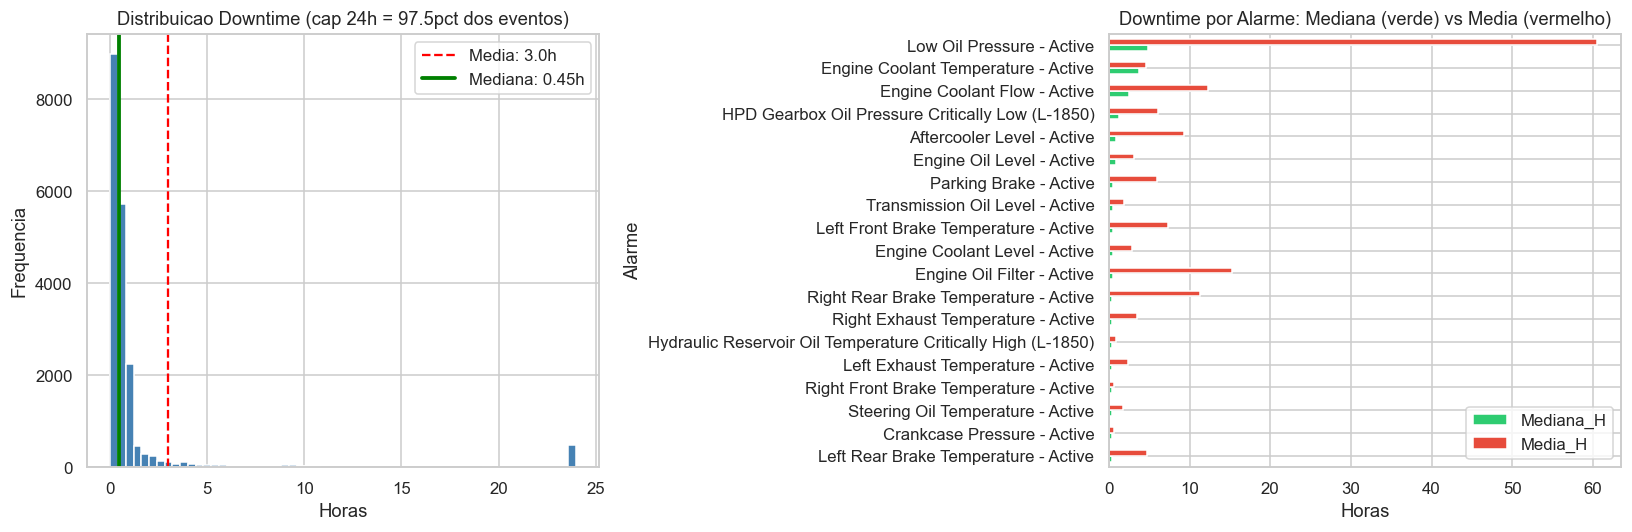


--- Downtime por Alarme ---
                                                              Mediana_H  Media_H     N
Alarme                                                                                
Low Oil Pressure - Active                                          4.80    60.52     5
Engine Coolant Temperature - Active                                3.68     4.60    23
Engine Coolant Flow - Active                                       2.46    12.26   113
HPD Gearbox Oil Pressure Critically Low (L-1850)                   1.22     6.13    15
Aftercooler Level - Active                                         0.92     9.30   824
Engine Oil Level - Active                                          0.86     3.12    55
Parking Brake - Active                                             0.55     5.98   487
Transmission Oil Level - Active                                    0.50     1.85  1426
Left Front Brake Temperature - Active                              0.49     7.28   170
Engine Coolant

In [2]:
from IPython import display
# Merge asof: DontGo -> primeiro retorno a Operando
dg_ev = df[df['Is_Dont_Go']==1].sort_values('Data_Evento').copy()
ap_op = df_ap[df_ap['Classe']=='Operando'].sort_values('Inicio').copy()
dg_ev['Data_Evento'] = dg_ev['Data_Evento'].astype('datetime64[ns]')
ap_op['Inicio']      = ap_op['Inicio'].astype('datetime64[ns]')

dt_real = pd.merge_asof(
    dg_ev[['TAG_Limpa','Data_Evento','Alarme']],
    ap_op[['Tag','Inicio']],
    left_on='Data_Evento', right_on='Inicio',
    left_by='TAG_Limpa', right_by='Tag',
    direction='forward'
)
dt_real['Downtime_H'] = (dt_real['Inicio'] - dt_real['Data_Evento']).dt.total_seconds() / 3600

# -- 1. Maquinas sem retorno a Operando --
nunca_voltou = dt_real['Inicio'].isna()
print(f'Total eventos DontGo: {len(dt_real):,}')
print(f'Com retorno: {(~nunca_voltou).sum():,} ({(~nunca_voltou).mean()*100:.1f}%)')
print(f'SEM retorno: {nunca_voltou.sum()} ({nunca_voltou.mean()*100:.1f}%)')
print('\nEquipamentos com mais eventos sem retorno:')
print(dt_real[nunca_voltou].groupby('TAG_Limpa').size().sort_values(ascending=False).head(8).to_string())

txt_908 = [
    '',
    '=== CA65908 - A Maquina Hibernada ===',
    'Concentra 124/198 (63pct) dos eventos sem retorno.',
    'Historico: Jan=12.001 | Fev=10.234 | Mar=9.220 | Abr=968 registros (colapso brusco).',
    'Silencio total em 17/Abr. Ultimo sinal: Oem Interface Timeout.',
    'Ultima semana: BAIXA VOLTAGEM + Aftercooler + Engine Coolant (deterioracao combinada).',
    'Apontamentos: HIBERNANDO de Abr ate 30/Jun.',
    'Conclusao: retirada por falha critica multipla (motor + arrefecimento + voltagem).',
    'Decisao: mantida no dataset - o modelo deve aprender o padrao que precede este desfecho.',
]
print('\n'.join(txt_908))

# -- 2. Distribuicao (validos, cap 720h) --
dt_val = dt_real[~nunca_voltou & (dt_real['Downtime_H'] > 0) & (dt_real['Downtime_H'] <= 720)].copy()
DOWNTIME_MEDIANA_H = dt_val['Downtime_H'].median()
DOWNTIME_MEDIA_H   = dt_val['Downtime_H'].mean()

print(f'\nEstatisticas Downtime (N={len(dt_val):,}):')
print(f'  Media:   {DOWNTIME_MEDIA_H:.2f}h  <- inflada por {(dt_val["Downtime_H"]>24).sum()} outliers acima de 24h')
print(f'  Mediana: {DOWNTIME_MEDIANA_H:.2f}h  <- representa 50pct dos casos')
print(f'  P75: {dt_val["Downtime_H"].quantile(0.75):.2f}h | P90: {dt_val["Downtime_H"].quantile(0.90):.2f}h')
print('Decisao: MEDIANA usada no calculo de ROI. Distribuicao right-skewed.')

# -- 3. Plot --
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(dt_val['Downtime_H'].clip(upper=24), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(DOWNTIME_MEDIA_H, color='red', linestyle='--', label=f'Media: {DOWNTIME_MEDIA_H:.1f}h')
axes[0].axvline(DOWNTIME_MEDIANA_H, color='green', linewidth=2.5, label=f'Mediana: {DOWNTIME_MEDIANA_H:.2f}h')
axes[0].set_title("Distribuicao Downtime (cap 24h = 97.5pct dos eventos)")
axes[0].set_xlabel('Horas'); axes[0].set_ylabel('Frequencia'); axes[0].legend()

dt_alarme = (dt_val.groupby('Alarme')['Downtime_H']
             .agg(['median','mean','count'])
             .rename(columns={'median':'Mediana_H','mean':'Media_H','count':'N'})
             .sort_values('Mediana_H', ascending=True))
dt_alarme[['Mediana_H','Media_H']].plot(kind='barh', ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Downtime por Alarme: Mediana (verde) vs Media (vermelho)')
axes[1].set_xlabel('Horas')
plt.tight_layout(); plt.show()

print('\n--- Downtime por Alarme ---')
print(dt_alarme.sort_values('Mediana_H', ascending=False).round(2).to_string())


## 2. Feature Engineering — Modelo Puro de Telemetria

**Regras aplicadas:**
1. `resample('8h')` por equipamento — grade calendária completa
2. `shift(1)` em todas as features — modelo prevê `[t]` usando apenas `[t-1]` e anteriores
3. Sem variáveis de operador — telemetria pura
4. Sem `dontgo_*` como feature — o modelo aprende os precursores físicos, não a repetição

**Três esquemas de features (um progressivamente mais rico):**
- **Esquema A**: Contagem por família física + rolling 24H / 72H
- **Esquema B**: Esquema A + *aceleração de fadiga* (delta turno atual vs média diária)
- **Esquema C**: Esquema A + *multi-família simultânea* (quantas famílias distintas ativas)
- **Esquema D**: Alarmes individuais dos 19 com Don't Go (CatBoost only)


In [3]:
# ── Definição das Famílias Físicas ──
FAMILIAS = {
    'freio':         ['Right Front Brake Temperature - Active',
                      'Left Front Brake Temperature - Active',
                      'Right Rear Brake Temperature - Active',
                      'Left Rear Brake Temperature - Active'],
    'motor':         ['Engine Coolant Level - Active',
                      'Engine Coolant Flow - Active',
                      'Engine Coolant Temperature - Active',
                      'Engine Oil Level - Active',
                      'Engine Oil Filter - Active'],
    'transmissao':   ['Transmission Oil Level - Active',
                      'Hydraulic Reservoir Oil Temperature Critically High (L-1850)',
                      'HPD Gearbox Oil Pressure Critically Low (L-1850)'],
    'pressao':       ['Crankcase Pressure - Active',
                      'Low Oil Pressure - Active'],
    'arrefecimento': ['Aftercooler Level - Active',
                      'Left Exhaust Temperature - Active',
                      'Right Exhaust Temperature - Active'],
    'outros':        ['Steering Oil Temperature - Active',
                      'Parking Brake - Active'],
}
TODOS_SINAIS = [a for grp in FAMILIAS.values() for a in grp]
FAM_COLS = [f'f_{k}' for k in FAMILIAS]

print("Gerando features (resample 8H + shift 1)...")
blocos = []

for tag, grupo in df.groupby('TAG_Limpa'):
    g = grupo.set_index('Data_Evento').sort_index()

    aggs = {
        'count_total': g['Is_Dont_Go'].resample('8h').count(),
        'Is_Dont_Go':  g['Is_Dont_Go'].resample('8h').sum(),
        'count_critico': g['Criticidade'].resample('8h').apply(
            lambda x: (x.str.contains('Critico', case=False, na=False)).sum()),
    }
    for familia, alarmes in FAMILIAS.items():
        aggs[f'f_{familia}'] = g['Alarme'].resample('8h').apply(
            lambda x, al=alarmes: x.isin(al).sum())
    for alarme in TODOS_SINAIS:
        col = 'a_' + re.sub(r'[^a-zA-Z0-9]', '_', alarme)[:40]
        aggs[col] = g['Alarme'].resample('8h').apply(lambda x, al=alarme: (x == al).sum())

    base = pd.DataFrame(aggs).fillna(0)

    # Rolling 24H (3×8H) e 72H (9×8H)
    for col in FAM_COLS + ['count_total','count_critico']:
        base[f'{col}_24H'] = base[col].rolling(3, min_periods=1).sum()
        base[f'{col}_72H'] = base[col].rolling(9, min_periods=1).sum()

    # Esquema B — Aceleração de Fadiga: delta turno atual vs média diária
    for col in FAM_COLS:
        media_24H = base[col].rolling(3, min_periods=1).mean().replace(0, np.nan)
        base[f'delta_{col}'] = (base[col] - media_24H).fillna(0)

    # Esquema C — Multi-Família Simultânea
    base['n_familias_ativas'] = (base[FAM_COLS] > 0).sum(axis=1)
    base['n_familias_ativas_24H'] = (
        pd.DataFrame({c: (base[f'{c}_24H'] > 0).astype(int) for c in FAM_COLS}).sum(axis=1)
        .rolling(3, min_periods=1).max())

    # is_pe — tipo do equipamento
    base['is_pe'] = int(tag.startswith('PE'))

    # ── SHIFT(1): garantia contra leakage ──
    feat_cols_shift = [c for c in base.columns if c != 'Is_Dont_Go']
    base[feat_cols_shift] = base[feat_cols_shift].shift(1)

    base['TAG_Limpa'] = tag
    blocos.append(base)

features = pd.concat(blocos).reset_index().rename(columns={'index': 'Data_Evento'})
features = features.dropna(subset=['count_total']).copy()
features['Target'] = (features['Is_Dont_Go'] > 0).astype(int)

print(f"Features: {features.shape[0]:,} linhas × {features.shape[1]} colunas")
print(f"Proporção Don't Go (janelas 8H): {features['Target'].mean()*100:.2f}%")


Gerando features (resample 8H + shift 1)...
Features: 15,418 linhas × 56 colunas
Proporção Don't Go (janelas 8H): 15.86%


## 3. Correlação das Features com o Target
Antes de treinar, analisamos quais features têm relação mensurável com o Don't Go. Features com correlação próxima de zero são ruído e podem ser removidas.


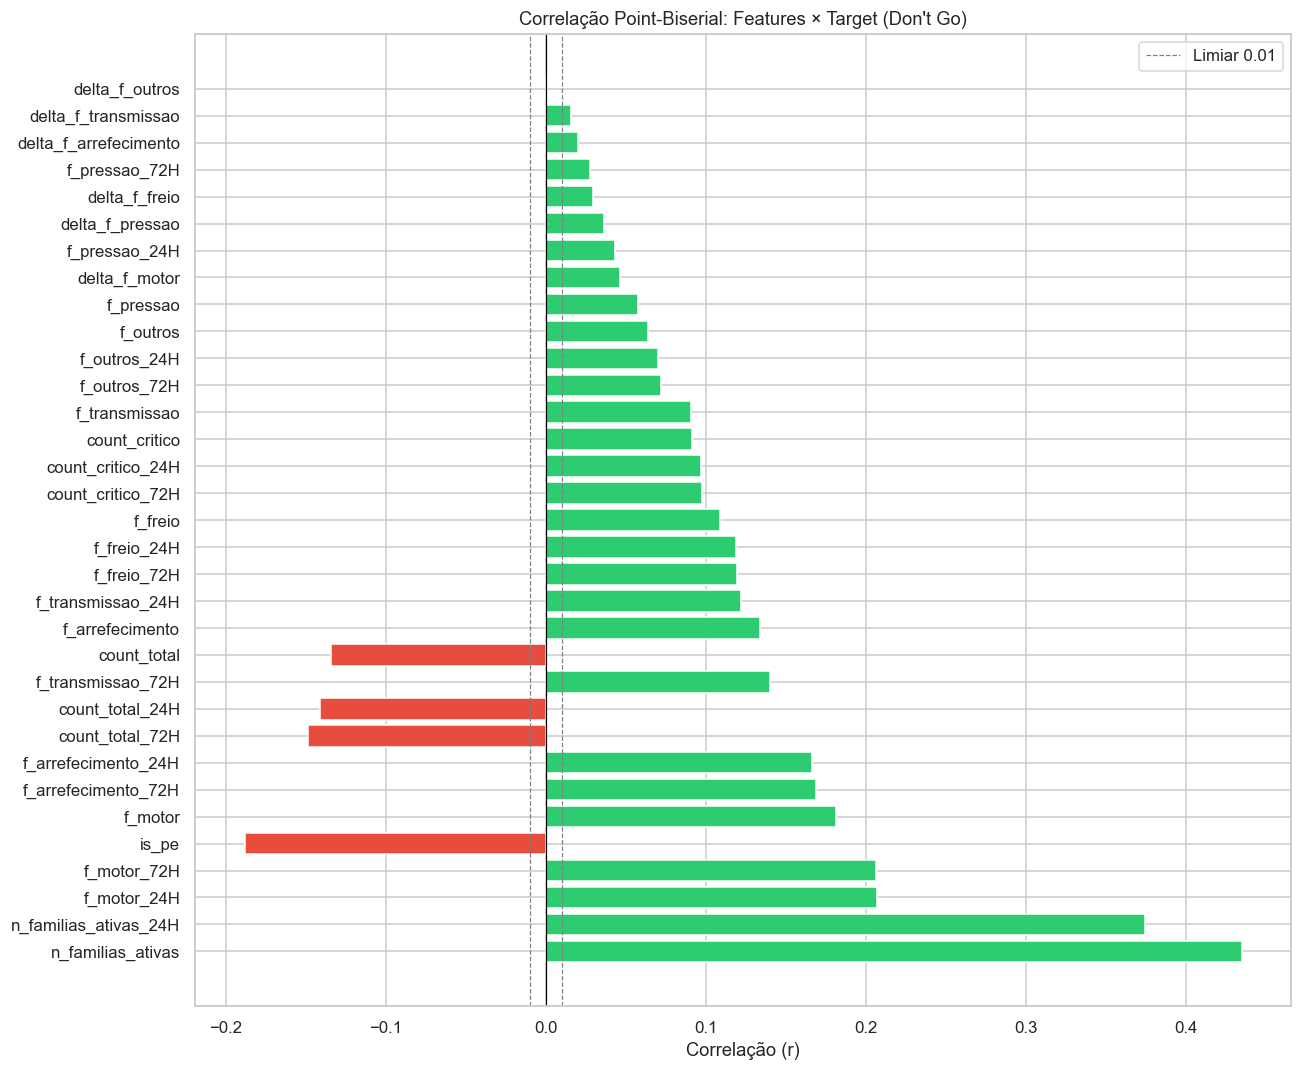

Features com |r| < 0.005 (candidatas a remoção): ['delta_f_outros']
                            r    p
n_familias_ativas      0.4348  0.0
n_familias_ativas_24H  0.3743  0.0
f_motor_24H            0.2072  0.0
f_motor_72H            0.2062  0.0
is_pe                 -0.1884  0.0
f_motor                0.1811  0.0
f_arrefecimento_72H    0.1687  0.0
f_arrefecimento_24H    0.1664  0.0
count_total_72H       -0.1490  0.0
count_total_24H       -0.1410  0.0


In [4]:
from scipy.stats import pointbiserialr

feat_num = [c for c in features.columns
            if c not in ['TAG_Limpa','Data_Evento','Is_Dont_Go','Target','TAG','Tipo','Alarme','Criticidade','Prefixo','Mes','Dia','Data_Dia']
            and not c.startswith('a_')]

corrs = {}
for c in feat_num:
    try:
        r, p = pointbiserialr(features[c].fillna(0), features['Target'])
        corrs[c] = {'r': r, 'p': p}
    except:
        pass

df_corr = pd.DataFrame(corrs).T.sort_values('r', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, max(6, len(df_corr)*0.3)))
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in df_corr['r']]
ax.barh(df_corr.index, df_corr['r'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.01, color='gray', linestyle='--', linewidth=0.8, label='Limiar 0.01')
ax.axvline(-0.01, color='gray', linestyle='--', linewidth=0.8)
ax.set_title("Correlação Point-Biserial: Features × Target (Don't Go)")
ax.set_xlabel("Correlação (r)")
ax.legend()
plt.tight_layout(); plt.show()

baixa_corr = df_corr[abs(df_corr['r']) < 0.005].index.tolist()
print(f"Features com |r| < 0.005 (candidatas a remoção): {baixa_corr}")
print(df_corr.head(10).round(4))


## 4. Split Temporal e Treinamento

Split cronológico estrito:
```
Jan–Abr (meses 1-4) → TREINO    (67%)
Mai     (mês 5)     → VALIDAÇÃO (17%)  ← usado no GridSearch/Optuna e no threshold
Jun     (mês 6)     → TESTE     (16%)  ← nunca visto durante treino ou tuning
```


In [5]:
COLS_META = ['TAG_Limpa','Data_Evento','Is_Dont_Go','Target','TAG','Tipo',
             'Alarme','Criticidade','Prefixo','Mes','Dia','Data_Dia']

ESQUEMAS_COLS = {
    'A': lambda df_f: [c for c in df_f.columns if c not in COLS_META
                        and not c.startswith('a_') and not c.startswith('delta_')
                        and c != 'n_familias_ativas' and c != 'n_familias_ativas_24H'],
    'B': lambda df_f: [c for c in df_f.columns if c not in COLS_META
                        and not c.startswith('a_')
                        and c != 'n_familias_ativas' and c != 'n_familias_ativas_24H'],
    'C': lambda df_f: [c for c in df_f.columns if c not in COLS_META
                        and not c.startswith('a_') and not c.startswith('delta_')],
    'D': lambda df_f: [c for c in df_f.columns if c not in COLS_META and not c.startswith('delta_')],
}

def preparar_split(df_f, esquema='A', frota='Combinado'):
    df_s = df_f.sort_values('Data_Evento').copy()
    df_s['is_pe'] = df_s['TAG_Limpa'].str.startswith('PE').astype(int)

    treino    = df_s[df_s['Data_Evento'].dt.month <= 4]
    validacao = df_s[df_s['Data_Evento'].dt.month == 5]
    teste     = df_s[df_s['Data_Evento'].dt.month == 6]

    feat_fn   = ESQUEMAS_COLS[esquema]
    feat_cols = [c for c in feat_fn(treino) if c in treino.columns]

    X_tr  = treino[feat_cols].fillna(0)
    y_tr  = treino['Target']
    X_val = validacao[feat_cols].fillna(0)
    y_val = validacao['Target']
    X_te  = teste[feat_cols].fillna(0)
    y_te  = teste['Target']

    sp = int((y_tr==0).sum() / max((y_tr==1).sum(), 1))

    print(f"[{frota}/Esq-{esquema}] Features: {len(feat_cols)} | scale_pos_weight: {sp}")
    print(f"  Treino [{treino.Data_Evento.min().date()}→{treino.Data_Evento.max().date()}]: "
          f"{len(X_tr):,} | DG: {y_tr.sum()} ({y_tr.mean()*100:.2f}%)")
    print(f"  Validação: {len(X_val):,} | DG: {y_val.sum()} ({y_val.mean()*100:.2f}%)")
    print(f"  Teste:     {len(X_te):,} | DG: {y_te.sum()} ({y_te.mean()*100:.2f}%)")
    return X_tr, y_tr, X_val, y_val, X_te, y_te, feat_cols, sp

tscv = TimeSeriesSplit(n_splits=5)
RESULTADOS = []

def avaliar(nome, modelo, X_te, y_te, threshold=0.5, frota='Combinado', esquema='A'):
    y_prob = modelo.predict_proba(X_te)[:,1] if hasattr(modelo,'predict_proba') else modelo.predict(X_te).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob) if y_te.nunique() > 1 else 0.0
    prec = (y_te[y_pred==1]).mean() if (y_pred==1).sum() > 0 else 0.0
    rec  = (y_pred[y_te==1]).mean() if (y_te==1).sum() > 0 else 0.0
    tp   = int(((y_pred==1) & (y_te==1)).sum())
    fp   = int(((y_pred==1) & (y_te==0)).sum())
    fn   = int(((y_pred==0) & (y_te==1)).sum())
    print(f"  [{nome}] Thr={threshold:.2f} | P={prec:.3f} R={rec:.3f} F1={f1:.4f} AUC={auc:.4f} TP={tp} FP={fp} FN={fn}")
    RESULTADOS.append({'Modelo':nome,'Frota':frota,'Esquema':esquema,'Threshold':round(threshold,2),
                       'Precision':round(prec,4),'Recall':round(rec,4),'F1':round(f1,4),
                       'AUC':round(auc,4),'TP':tp,'FP':fp,'FN':fn})
    return modelo

def otimizar_threshold(modelo, X_val, y_val, criterio='f1'):
    """Otimiza o threshold no conjunto de validação (nunca no teste)."""
    probs = modelo.predict_proba(X_val)[:,1]
    precs, recs, thrs = precision_recall_curve(y_val, probs)
    f1s = 2 * precs * recs / (precs + recs + 1e-9)
    best_idx = np.argmax(f1s[:-1])
    thr_f1 = float(thrs[best_idx])
    print(f"  → Threshold ótimo (F1): {thr_f1:.3f} | F1_val: {f1s[best_idx]:.4f}")
    return thr_f1

print("=== Split Principal: Esquema A — Frota Combinada ===")
X_tr, y_tr, X_val, y_val, X_te, y_te, feat_A, sp = preparar_split(features, 'A')


=== Split Principal: Esquema A — Frota Combinada ===
[Combinado/Esq-A] Features: 25 | scale_pos_weight: 4
  Treino [2025-01-01→2025-04-30]: 10,358 | DG: 1881 (18.16%)
  Validação: 2,594 | DG: 284 (10.95%)
  Teste:     2,466 | DG: 281 (11.39%)


In [6]:
# ════ BASELINE ════
print("\n=== Baseline ===")
dummy = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
avaliar('Baseline', dummy, X_te, y_te)

# ════ RANDOM FOREST ════
print("\n=== Random Forest — GridSearch ===")
rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                  {'n_estimators':[200,500],'max_depth':[6,10,None],'class_weight':['balanced']},
                  cv=tscv, scoring='f1', n_jobs=-1)
rf.fit(X_tr, y_tr)
print(f"  Best: {rf.best_params_}")
thr_rf = otimizar_threshold(rf.best_estimator_, X_val, y_val)
avaliar('RandomForest_A', rf.best_estimator_, X_te, y_te, threshold=thr_rf)

# ════ XGBOOST ════
print("\n=== XGBoost — RandomizedSearch ===")
xgb_p = {'n_estimators':[300,500,1000],'max_depth':[4,6,8],
          'learning_rate':[0.01,0.05,0.1],'subsample':[0.7,0.9],
          'colsample_bytree':[0.7,0.9],'scale_pos_weight':[sp, sp//2]}
xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False),
    xgb_p, n_iter=30, cv=tscv, scoring='f1', random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr)
print(f"  Best: {xgb.best_params_}")
thr_xgb = otimizar_threshold(xgb.best_estimator_, X_val, y_val)
avaliar('XGBoost_A', xgb.best_estimator_, X_te, y_te, threshold=thr_xgb)

# ════ LIGHTGBM ════
print("\n=== LightGBM — RandomizedSearch ===")
lgb = RandomizedSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    {'n_estimators':[300,500,1000],'max_depth':[4,6,8],
     'learning_rate':[0.01,0.05,0.1],'num_leaves':[31,63,127],'class_weight':['balanced']},
    n_iter=30, cv=tscv, scoring='f1', random_state=42, n_jobs=-1)
lgb.fit(X_tr, y_tr)
print(f"  Best: {lgb.best_params_}")
thr_lgb = otimizar_threshold(lgb.best_estimator_, X_val, y_val)
avaliar('LightGBM_A', lgb.best_estimator_, X_te, y_te, threshold=thr_lgb)

# ════ HISTGRADIENTBOOSTING ════
print("\n=== HistGradientBoosting — GridSearch ===")
hgb = GridSearchCV(HistGradientBoostingClassifier(random_state=42),
                   {'max_iter':[200,500],'max_depth':[4,6],'learning_rate':[0.05,0.1],'class_weight':['balanced']},
                   cv=tscv, scoring='f1', n_jobs=-1)
hgb.fit(X_tr, y_tr)
thr_hgb = otimizar_threshold(hgb.best_estimator_, X_val, y_val)
avaliar('HistGB_A', hgb.best_estimator_, X_te, y_te, threshold=thr_hgb)

# ════ CATBOOST — OPTUNA 100 TRIALS ════
print("\n=== CatBoost + Optuna (100 trials) — Esquema A ===")
def obj_cat(trial, Xt=X_tr, yt=y_tr, sp_=sp):
    p = {'iterations': trial.suggest_int('iterations', 200, 1000),
         'depth': trial.suggest_int('depth', 4, 10),
         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
         'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, sp_),
         'random_seed': 42, 'verbose': 0}
    scores = [f1_score(yt.iloc[vi], CatBoostClassifier(**p).fit(Xt.iloc[ti], yt.iloc[ti], verbose=0).predict(Xt.iloc[vi]), zero_division=0)
              for ti, vi in tscv.split(Xt)]
    return np.mean(scores)

study_A = optuna.create_study(direction='maximize')
study_A.optimize(obj_cat, n_trials=100, show_progress_bar=True)
cat_A = CatBoostClassifier(**study_A.best_params, random_seed=42, verbose=0).fit(X_tr, y_tr)
thr_cat_A = otimizar_threshold(cat_A, X_val, y_val)
avaliar('CatBoost_A', cat_A, X_te, y_te, threshold=thr_cat_A)



=== Baseline ===
  [Baseline] Thr=0.50 | P=0.000 R=0.000 F1=0.0000 AUC=0.5000 TP=0 FP=0 FN=281

=== Random Forest — GridSearch ===
  Best: {'class_weight': 'balanced', 'max_depth': 6, 'n_estimators': 200}
  → Threshold ótimo (F1): 0.622 | F1_val: 0.4213
  [RandomForest_A] Thr=0.62 | P=0.498 R=0.423 F1=0.4577 AUC=0.8361 TP=119 FP=120 FN=162

=== XGBoost — RandomizedSearch ===
  Best: {'subsample': 0.7, 'scale_pos_weight': 4, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  → Threshold ótimo (F1): 0.404 | F1_val: 0.4117
  [XGBoost_A] Thr=0.40 | P=0.343 R=0.655 F1=0.4499 AUC=0.8436 TP=184 FP=353 FN=97

=== LightGBM — RandomizedSearch ===
  Best: {'num_leaves': 63, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'class_weight': 'balanced'}
  → Threshold ótimo (F1): 0.511 | F1_val: 0.4201
  [LightGBM_A] Thr=0.51 | P=0.400 R=0.591 F1=0.4770 AUC=0.8448 TP=166 FP=249 FN=115

=== HistGradientBoosting — GridSearch ===
  → Threshold ótimo (F1): 0

  0%|          | 0/100 [00:00<?, ?it/s]

  → Threshold ótimo (F1): 0.413 | F1_val: 0.4128
  [CatBoost_A] Thr=0.41 | P=0.400 R=0.598 F1=0.4793 AUC=0.8448 TP=168 FP=252 FN=113


CatBoostClassifier(depth=6, iterations=502, l2_leaf_reg=6.753657741854105, learning_rate=0.01186553317106501, random_seed=42, scale_pos_weight=2.8816051099911344, verbose=0)

In [7]:
# ════ ESQUEMA B (Aceleração) ════
print("\n=== Esquema B — Aceleração de Fadiga ===")
X_trB, y_trB, X_valB, y_valB, X_teB, y_teB, feat_B, spB = preparar_split(features, 'B')

xgbB = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss',
                     use_label_encoder=False, scale_pos_weight=spB,
                     n_estimators=500, max_depth=6, learning_rate=0.05)
xgbB.fit(X_trB, y_trB)
thr_xgbB = otimizar_threshold(xgbB, X_valB, y_valB)
avaliar('XGBoost_B', xgbB, X_teB, y_teB, threshold=thr_xgbB, esquema='B')

study_B = optuna.create_study(direction='maximize')
study_B.optimize(lambda t: obj_cat(t, Xt=X_trB, yt=y_trB, sp_=spB), n_trials=100, show_progress_bar=True)
cat_B = CatBoostClassifier(**study_B.best_params, random_seed=42, verbose=0).fit(X_trB, y_trB)
thr_cat_B = otimizar_threshold(cat_B, X_valB, y_valB)
avaliar('CatBoost_B', cat_B, X_teB, y_teB, threshold=thr_cat_B, esquema='B')

# ════ ESQUEMA C (Multi-Família) ════
print("\n=== Esquema C — Multi-Família Simultânea ===")
X_trC, y_trC, X_valC, y_valC, X_teC, y_teC, feat_C, spC = preparar_split(features, 'C')

study_C = optuna.create_study(direction='maximize')
study_C.optimize(lambda t: obj_cat(t, Xt=X_trC, yt=y_trC, sp_=spC), n_trials=100, show_progress_bar=True)
cat_C = CatBoostClassifier(**study_C.best_params, random_seed=42, verbose=0).fit(X_trC, y_trC)
thr_cat_C = otimizar_threshold(cat_C, X_valC, y_valC)
avaliar('CatBoost_C', cat_C, X_teC, y_teC, threshold=thr_cat_C, esquema='C')

# ════ ESQUEMA D (Individual — CatBoost) ════
print("\n=== Esquema D — Alarmes Individuais (CatBoost) ===")
X_trD, y_trD, X_valD, y_valD, X_teD, y_teD, feat_D, spD = preparar_split(features, 'D')

study_D = optuna.create_study(direction='maximize')
study_D.optimize(lambda t: obj_cat(t, Xt=X_trD, yt=y_trD, sp_=spD), n_trials=100, show_progress_bar=True)
cat_D = CatBoostClassifier(**study_D.best_params, random_seed=42, verbose=0).fit(X_trD, y_trD)
thr_cat_D = otimizar_threshold(cat_D, X_valD, y_valD)
avaliar('CatBoost_D', cat_D, X_teD, y_teD, threshold=thr_cat_D, esquema='D')



=== Esquema B — Aceleração de Fadiga ===
[Combinado/Esq-B] Features: 31 | scale_pos_weight: 4
  Treino [2025-01-01→2025-04-30]: 10,358 | DG: 1881 (18.16%)
  Validação: 2,594 | DG: 284 (10.95%)
  Teste:     2,466 | DG: 281 (11.39%)
  → Threshold ótimo (F1): 0.334 | F1_val: 0.3869
  [XGBoost_B] Thr=0.33 | P=0.327 R=0.641 F1=0.4327 AUC=0.8235 TP=180 FP=371 FN=101


  0%|          | 0/100 [00:00<?, ?it/s]

  → Threshold ótimo (F1): 0.444 | F1_val: 0.4086
  [CatBoost_B] Thr=0.44 | P=0.434 R=0.566 F1=0.4915 AUC=0.8437 TP=159 FP=207 FN=122

=== Esquema C — Multi-Família Simultânea ===
[Combinado/Esq-C] Features: 27 | scale_pos_weight: 4
  Treino [2025-01-01→2025-04-30]: 10,358 | DG: 1881 (18.16%)
  Validação: 2,594 | DG: 284 (10.95%)
  Teste:     2,466 | DG: 281 (11.39%)


  0%|          | 0/100 [00:00<?, ?it/s]

  → Threshold ótimo (F1): 0.383 | F1_val: 0.4221
  [CatBoost_C] Thr=0.38 | P=0.391 R=0.598 F1=0.4726 AUC=0.8361 TP=168 FP=262 FN=113

=== Esquema D — Alarmes Individuais (CatBoost) ===
[Combinado/Esq-D] Features: 46 | scale_pos_weight: 4
  Treino [2025-01-01→2025-04-30]: 10,358 | DG: 1881 (18.16%)
  Validação: 2,594 | DG: 284 (10.95%)
  Teste:     2,466 | DG: 281 (11.39%)


  0%|          | 0/100 [00:00<?, ?it/s]

  → Threshold ótimo (F1): 0.362 | F1_val: 0.4280
  [CatBoost_D] Thr=0.36 | P=0.355 R=0.655 F1=0.4600 AUC=0.8382 TP=184 FP=335 FN=97


CatBoostClassifier(depth=8, iterations=379, l2_leaf_reg=9.17775034911447, learning_rate=0.016341028870261558, random_seed=42, scale_pos_weight=2.6072415115625196, verbose=0)

In [8]:
# ════ EXPERIMENTO SEPARADO CA vs PE (Esquema A) ════
print("\n=== Experimento Separado — CA e PE ===")
modelos_separados = {}
for pref in ['CA', 'PE']:
    print(f"\n--- {pref} ---")
    df_f = features[features['TAG_Limpa'].str.startswith(pref)].copy()
    Xtr_f, ytr_f, Xval_f, yval_f, Xte_f, yte_f, _, sp_f = preparar_split(df_f, 'A', frota=pref)

    study_f = optuna.create_study(direction='maximize')
    study_f.optimize(lambda t: obj_cat(t, Xt=Xtr_f, yt=ytr_f, sp_=sp_f), n_trials=100, show_progress_bar=True)
    cat_f = CatBoostClassifier(**study_f.best_params, random_seed=42, verbose=0).fit(Xtr_f, ytr_f)
    thr_f = otimizar_threshold(cat_f, Xval_f, yval_f)
    avaliar(f'CatBoost_{pref}_A', cat_f, Xte_f, yte_f, threshold=thr_f, frota=pref)
    modelos_separados[pref] = cat_f



=== Experimento Separado — CA e PE ===

--- CA ---
[CA/Esq-A] Features: 25 | scale_pos_weight: 3
  Treino [2025-01-01→2025-04-30]: 8,563 | DG: 1865 (21.78%)
  Validação: 2,129 | DG: 277 (13.01%)
  Teste:     2,027 | DG: 279 (13.76%)


  0%|          | 0/100 [00:00<?, ?it/s]

  → Threshold ótimo (F1): 0.506 | F1_val: 0.4168
  [CatBoost_CA_A] Thr=0.51 | P=0.477 R=0.509 F1=0.4922 AUC=0.8155 TP=142 FP=156 FN=137

--- PE ---
[PE/Esq-A] Features: 25 | scale_pos_weight: 111
  Treino [2025-01-01→2025-04-30]: 1,795 | DG: 16 (0.89%)
  Validação: 465 | DG: 7 (1.51%)
  Teste:     439 | DG: 2 (0.46%)


  0%|          | 0/100 [00:00<?, ?it/s]

  → Threshold ótimo (F1): 0.247 | F1_val: 0.1176
  [CatBoost_PE_A] Thr=0.25 | P=0.000 R=0.000 F1=0.0000 AUC=0.8947 TP=0 FP=7 FN=2


## 5. Resultados, Threshold e ROI

### Lógica do Cálculo de ROI (vs. Manutenção Reativa — baseline)

| Cenário | Custo Baseline | Custo com Modelo |
|---|---|---|
| **TP** — Previu e fez manutenção preventiva | `downtime_medio × R$/h_emergência` | `downtime_medio × 0.5 × R$/h_planejado` |
| **FP** — Previu mas sem falha | R$ 0 | Custo da inspeção desnecessária |
| **FN** — Não previu, falha aconteceu | `downtime_medio × R$/h_emergência` | `downtime_medio × R$/h_emergência` (igual) |
| **TN** | R$ 0 | R$ 0 |

**ROI = TP × Economia_por_TP − FP × Custo_FP**

Onde `Economia_por_TP = downtime_medio × (R$/h_emergência − 0.5 × R$/h_planejado)`

> Modelo com zero TP e zero FP (Baseline) → ROI = **0** (referência)  
> Modelo com muitos FP e poucos TP → ROI **negativo**  
> Modelo eficiente → ROI **positivo**


Economia por Don't Go evitado (TP): R$ 2,839
Custo de inspeção desnecessária (FP): R$ 800
ROI Baseline (sem modelo): R$ 0 (referência)

=== TABELA COMPARATIVA FINAL ===


,Modelo,Esquema,Frota,Threshold,F1,AUC,TP,FP,FN,ROI_R$
0,CatBoost_B,B,Combinado,0.44,0.4915,0.8437,159,207,122,"R$ 285,730"
1,HistGB_A,A,Combinado,0.57,0.4885,0.8485,149,180,132,"R$ 278,945"
2,CatBoost_CA_A,A,CA,0.51,0.4922,0.8155,142,156,137,"R$ 278,275"
3,CatBoost_A,A,Combinado,0.41,0.4793,0.8448,168,252,113,"R$ 275,277"
4,LightGBM_A,A,Combinado,0.51,0.4770,0.8448,166,249,115,"R$ 272,000"
5,CatBoost_C,C,Combinado,0.38,0.4726,0.8361,168,262,113,"R$ 267,277"
6,CatBoost_D,D,Combinado,0.36,0.4600,0.8382,184,335,97,"R$ 254,294"
7,RandomForest_A,A,Combinado,0.62,0.4577,0.8361,119,120,162,"R$ 241,788"
8,XGBoost_A,A,Combinado,0.40,0.4499,0.8436,184,353,97,"R$ 239,894"
9,XGBoost_B,B,Combinado,0.33,0.4327,0.8235,180,371,101,"R$ 214,140"



Melhor modelo: CatBoost_B | F1=0.4915 | ROI=R$ 285,730
  TP=159 | FP=207 | FN=122
  Benefício: R$ 451,330 | Custo FP: R$ 165,600


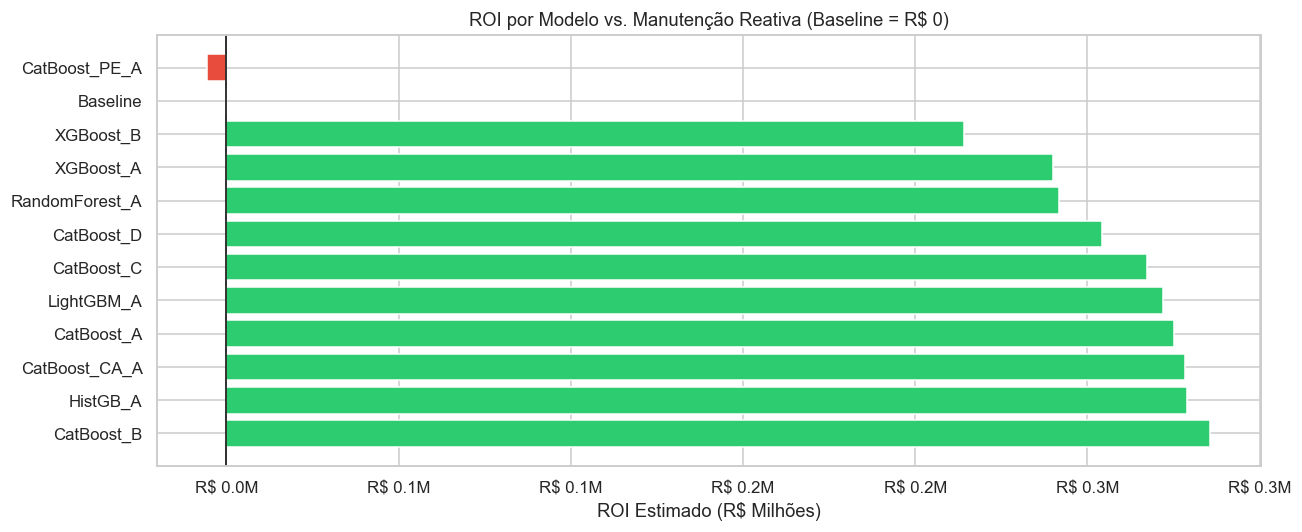

In [9]:
from IPython.display import display
# ── Parâmetros de custo (conservadores, ajustáveis) ──
CUSTO_H_EMERGENCIA  = 8_000   # R$/hora — parada não planejada: perda de produção + custo urgente
CUSTO_H_PLANEJADO   = 3_500   # R$/hora — manutenção agendada (mais eficiente, 50% do tempo)
CUSTO_FALSO_POS     = 800     # R$/evento — inspeção + parada preventiva desnecessária

FATOR_TEMPO_PLANEJADO = 0.5   # Manutenção planejada leva ~50% do tempo da não-planejada
ECONOMIA_POR_TP = DOWNTIME_MEDIANA_H * CUSTO_H_EMERGENCIA - DOWNTIME_MEDIANA_H * FATOR_TEMPO_PLANEJADO * CUSTO_H_PLANEJADO

print(f"Economia por Don't Go evitado (TP): R$ {ECONOMIA_POR_TP:,.0f}")
print(f"Custo de inspeção desnecessária (FP): R$ {CUSTO_FALSO_POS:,.0f}")
print(f"ROI Baseline (sem modelo): R$ 0 (referência)")

# ── Tabela de Resultados + ROI ──
df_res = pd.DataFrame(RESULTADOS)

df_res['ROI_R$']       = df_res['TP'] * ECONOMIA_POR_TP - df_res['FP'] * CUSTO_FALSO_POS
df_res['Beneficio_R$'] = df_res['TP'] * ECONOMIA_POR_TP
df_res['Custo_FP_R$']  = df_res['FP'] * CUSTO_FALSO_POS
df_res = df_res.sort_values('ROI_R$', ascending=False).reset_index(drop=True)

print("\n=== TABELA COMPARATIVA FINAL ===")
display(df_res[['Modelo','Esquema','Frota','Threshold','F1','AUC','TP','FP','FN','ROI_R$']]
        .style
        .background_gradient(cmap='RdYlGn', subset=['F1','ROI_R$'])
        .format({'F1':'{:.4f}','AUC':'{:.4f}','ROI_R$':'R$ {:,.0f}','Threshold':'{:.2f}'}))

melhor = df_res.iloc[0]
print(f"\nMelhor modelo: {melhor['Modelo']} | F1={melhor['F1']:.4f} | ROI=R$ {melhor['ROI_R$']:,.0f}")
print(f"  TP={melhor['TP']} | FP={melhor['FP']} | FN={melhor['FN']}")
print(f"  Benefício: R$ {melhor['Beneficio_R$']:,.0f} | Custo FP: R$ {melhor['Custo_FP_R$']:,.0f}")

# ── Gráfico ROI ──
fig, ax = plt.subplots(figsize=(12, max(5, len(df_res)*0.4)))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_res['ROI_R$']]
ax.barh(df_res['Modelo'], df_res['ROI_R$'] / 1e6, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("ROI Estimado (R$ Milhões)")
ax.set_title("ROI por Modelo vs. Manutenção Reativa (Baseline = R$ 0)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.1f}M'))
plt.tight_layout(); plt.show()


## 6. Interpretabilidade — SHAP (Melhor Modelo)


=== SHAP — Importância Global ===


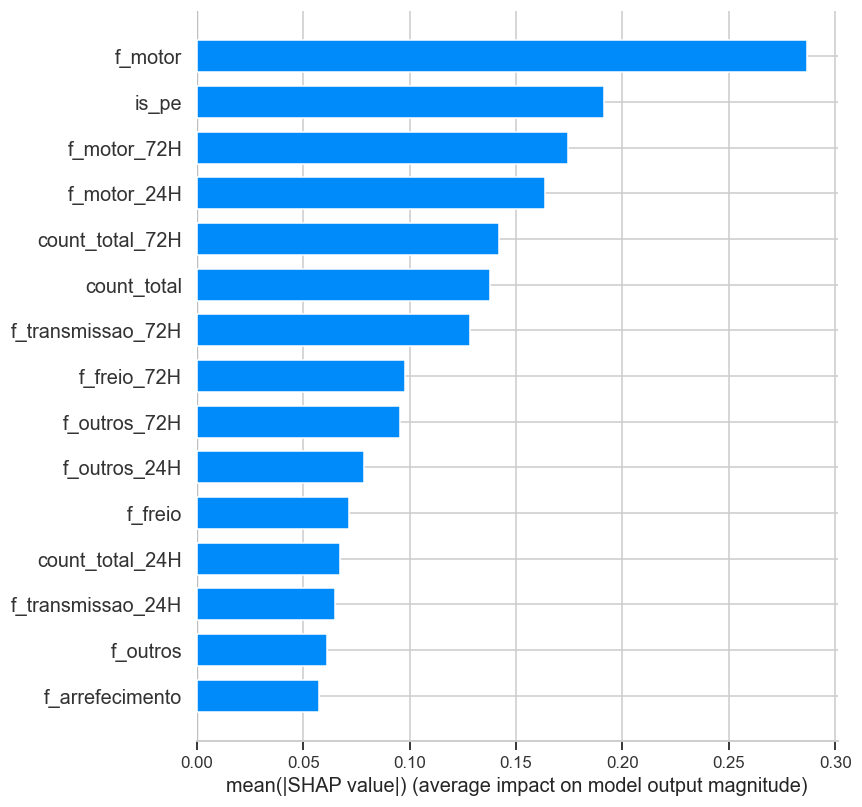


=== SHAP — Beeswarm ===


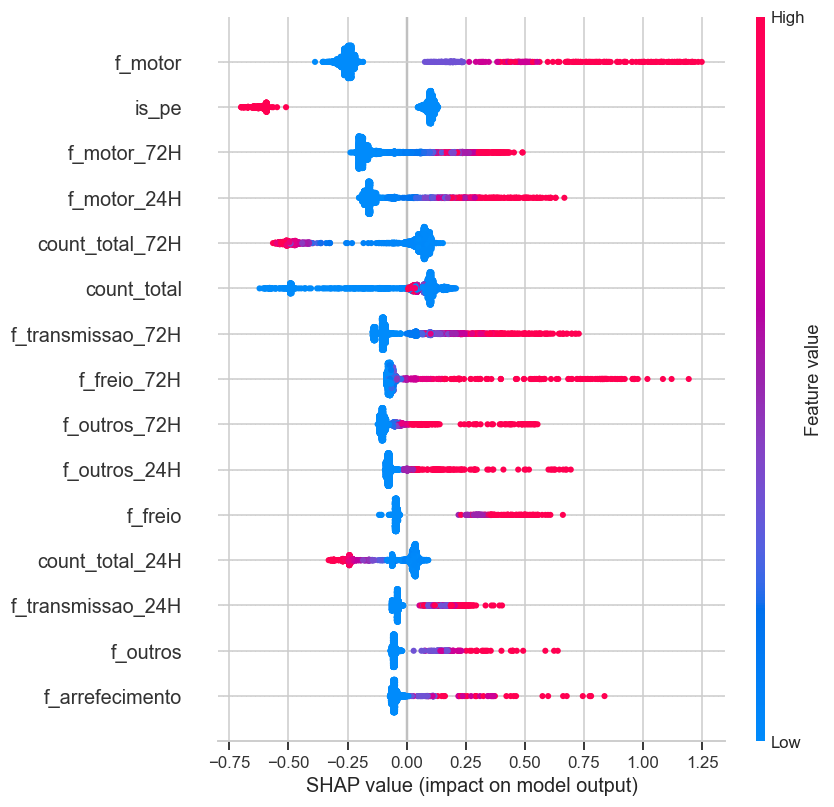

In [10]:
import shap

modelo_shap = cat_A  # melhor modelo CatBoost — ajustar se necessário
explainer   = shap.TreeExplainer(modelo_shap)
shap_values = explainer.shap_values(X_te)

print("=== SHAP — Importância Global ===")
shap.summary_plot(shap_values, X_te, plot_type='bar', max_display=15, show=True)

print("\n=== SHAP — Beeswarm ===")
shap.summary_plot(shap_values, X_te, max_display=15, show=True)


## 7. Persistência do Modelo Vencedor


In [11]:
melhor_nome = df_res.iloc[0]['Modelo']
modelo_map  = {'CatBoost_A': cat_A, 'CatBoost_B': cat_B, 'CatBoost_C': cat_C,
               'CatBoost_D': cat_D, 'XGBoost_A': xgb.best_estimator_,
               'LightGBM_A': lgb.best_estimator_, 'RandomForest_A': rf.best_estimator_}
modelo_final   = modelo_map.get(melhor_nome, cat_A)
threshold_final = df_res.iloc[0]['Threshold']

caminho = r'c:\\TT\\AntiGravity\\Vale_\\models\\modelo_nb04_telemetria_puro.pkl'
joblib.dump({'modelo': modelo_final, 'threshold': threshold_final,
             'features': feat_A, 'esquema': df_res.iloc[0]['Esquema']}, caminho)

print(f"Modelo salvo: {caminho}")
print(f"Modelo: {melhor_nome} | Threshold: {threshold_final:.3f}")
print(f"Features ({len(feat_A)}): {feat_A}")


Modelo salvo: c:\\TT\\AntiGravity\\Vale_\\models\\modelo_nb04_telemetria_puro.pkl
Modelo: CatBoost_B | Threshold: 0.440
Features (25): ['count_total', 'count_critico', 'f_freio', 'f_motor', 'f_transmissao', 'f_pressao', 'f_arrefecimento', 'f_outros', 'f_freio_24H', 'f_freio_72H', 'f_motor_24H', 'f_motor_72H', 'f_transmissao_24H', 'f_transmissao_72H', 'f_pressao_24H', 'f_pressao_72H', 'f_arrefecimento_24H', 'f_arrefecimento_72H', 'f_outros_24H', 'f_outros_72H', 'count_total_24H', 'count_total_72H', 'count_critico_24H', 'count_critico_72H', 'is_pe']
